Creates frequency tables of TE families per species (intact, solo, disrupted), plots LTR identity distributions (boxplots, violin plots) by species and centromere architecture. Logit-transforms identity values.
Output: Figures for Chapter 1 (LTR identity distributions, TE abundance per family per species).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [2]:
# galadriel was only found in 3 samples and there is only ~30 elements
exclude_classes=["Ty3/gypsy|chromovirus|Galadriel"]

In [3]:
chr_names_path = "data/chromosome_sizes.tsv"
chr_names_df = pd.read_csv(chr_names_path, sep='\t')
included_accessions = chr_names_df['chr'].tolist()

In [4]:
gs = pd.read_csv("data/metadata.tsv", sep="\t")
colnames=['Order',
 'Species',
 'Chromosome_number_(n)',
 'Assembly_size_(Mb)',
 'Chromosome_size_(Mb)',
 'Chromosomes_in_analysis',
 'Assembly_size_in_analysis_(Mb)',
 'Accession',
 'Family',
 'Centromere_architecture',
 'Included_chromosomes',
 'Gaps_per_chr',
 'Gaps_per_Mb',
 'Busco_pct',
 'Short_label']
gs.columns = colnames

sample_order = gs['Species'].tolist()
short_labels = gs['Short_label'].tolist()

In [5]:
dante_path = "data/intact_elements_dante.tsv"
dante = pd.read_csv(dante_path, sep="\t")
dante = dante[dante['chr'].isin(included_accessions)]
dante = dante[['ID','sample','Class', 'Rank','LTR_identity', 'LTR_length']]

dante = dante[~dante['Class'].isin(exclude_classes)]

In [6]:
# make frequency table based on the smaple and class
dante_freq = dante.groupby(['sample','Class']).size().reset_index(name='count')
dante_freq = dante_freq.pivot(index='sample', columns='Class', values='count').fillna(0).reset_index()
# join the frequency table with the metadata columns 
dante_freq = dante_freq.merge(gs[['Species', 'Centromere_architecture', 'Assembly_size_in_analysis_(Mb)', 'Short_label']], left_on='sample', right_on='Species', how='right')
dante_freq = dante_freq.drop(columns=['Species'])
# remove rows with missing values
dante_freq = dante_freq.dropna()

In [7]:
# calculate the frequency of each class per Mb
LTRTE_columns = dante_freq.columns
# exclude sample, Centromere_, Assembly_size_in_analysis_(Mb) from the list of columns
LTRTE_columns = [x for x in LTRTE_columns if x not in ['sample', 'Centromere_architecture', 'Assembly_size_in_analysis_(Mb)', 'Short_label']]

for col in LTRTE_columns:
    dante_freq[col] = dante_freq[col]/dante_freq['Assembly_size_in_analysis_(Mb)']


In [8]:
# calculate the most abundant LTRTE class
# Replace frequencies in each LTR column by its order per row

order_df = pd.DataFrame()
def get_order(row):
    return row[LTRTE_columns].rank(ascending=False, method='min').astype(int)

order_df = dante_freq.apply(get_order, axis=1)
order_df['sample'] = dante_freq['sample']

# Melt the order_df to long format
order_df_melted = order_df.melt(id_vars=['sample'], var_name='Class', value_name='Rank')

# calculate the mean rank for each class
mean_rank = order_df_melted.groupby('Class')['Rank'].mean().reset_index()
mean_rank = mean_rank.sort_values(by='Rank')

family_order = mean_rank['Class'].tolist()
family_short_labels = [x.split("|")[-1] for x in family_order]


In [9]:
solo_path = "data/solo_elements.tsv"
solo = pd.read_csv(solo_path, sep="\t")
solo = solo[solo['chr'].isin(included_accessions)]
solo = solo[['id', 'sample', 'Class']]
solo = solo[~solo['Class'].isin(exclude_classes)]
# filter the solo elements based on the samples
solo_freq = solo.groupby(['sample', 'Class']).size().reset_index(name='count')
solo_freq = solo_freq.pivot(index='sample', columns='Class', values='count').fillna(0).reset_index()
solo_freq = solo_freq.merge(gs[['Species', 'Centromere_architecture', 'Assembly_size_in_analysis_(Mb)', 'Short_label']], left_on='sample', right_on='Species', how='right')
solo_freq = solo_freq.drop(columns=['Species'])
solo_freq = solo_freq.dropna()





In [10]:
LTRTE_columns = solo_freq.columns
LTRTE_columns = [x for x in LTRTE_columns if x not in ['sample', 'Centromere_architecture', 'Assembly_size_in_analysis_(Mb)', 'Short_label']]
for col in LTRTE_columns:
    solo_freq[col] = solo_freq[col]/solo_freq['Assembly_size_in_analysis_(Mb)']


In [11]:
disrupted_path = "data/partial_elements_dante.tsv"
disrupted = pd.read_csv(disrupted_path, sep="\t")
disrupted = disrupted[disrupted['chr'].isin(included_accessions)]
disrupted = disrupted[['ID','sample','Class', 'Rank','LTR_identity']]
disrupted = disrupted[~disrupted['Class'].isin(exclude_classes)]
# filter the disrupted elements based on the samples
disrupted_freq = disrupted.groupby(['sample', 'Class']).size().reset_index(name='count')
disrupted_freq = disrupted_freq.pivot(index='sample', columns='Class', values='count').fillna(0).reset_index()
disrupted_freq = disrupted_freq.merge(gs[['Species', 'Centromere_architecture', 'Assembly_size_in_analysis_(Mb)',  'Short_label']], left_on='sample', right_on='Species', how='right')
disrupted_freq = disrupted_freq.drop(columns=['Species'])
disrupted_freq = disrupted_freq.dropna()


In [12]:
LTRTE_columns = disrupted_freq.columns
LTRTE_columns = [x for x in LTRTE_columns if x not in ['sample', 'Centromere_architecture', 'Assembly_size_in_analysis_(Mb)', 'Short_label']]
for col in LTRTE_columns:
    disrupted_freq[col] = disrupted_freq[col]/disrupted_freq['Assembly_size_in_analysis_(Mb)']


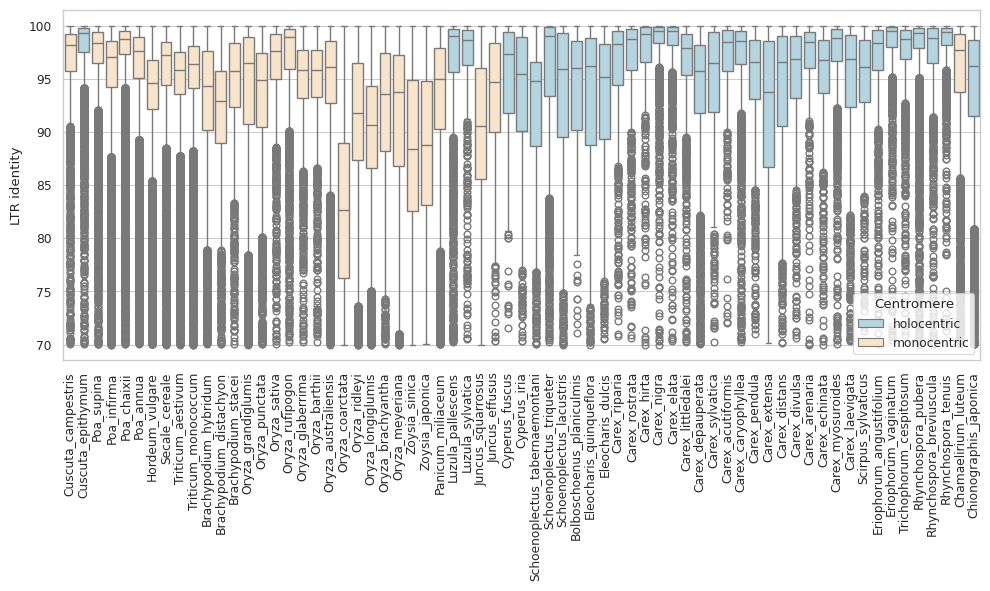

In [13]:
# plot LTR identity per sample with color based on Centromere
sns.set_theme()
sns.set_context("paper")
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Create a color palette for Centromere
palette = {"holocentric": "lightblue", "monocentric": "bisque"}

# Merge dante with gs to include Centromere information
dante_with_centromere = dante.merge(gs[['Species', 'Centromere_architecture', 'Short_label']], left_on='sample', right_on='Species', how='left')

sns.boxplot(data=dante_with_centromere, x="sample", y="LTR_identity", hue="Centromere_architecture", palette=palette, dodge=False, order=sample_order)
plt.xticks(rotation=90)
plt.ylabel("LTR identity")
plt.xlabel("")
plt.title("")
plt.tight_layout()

plt.legend(title="Centromere", loc="lower right")
plt.savefig("data/figures/LTR_identity.png", dpi=300)

# Logit transformation of percentage values

~3% of elements have 100% LTR identity, which causes problems with logit transformation. 100% values are clipped by epsilon.
The second largest value is 99.99%, so epsilon is set to 0.0001.

In [14]:
eps=0.0001

def logit_from_percent(p, eps=eps):
    p = p/100
    p = np.clip(p, eps, 1-eps)
    return np.log(p/(1-p))

def logit_to_percent(x, pos):
    """Convert logit value to percentage for axis labels"""
    proportion = np.exp(x) / (1 + np.exp(x))
    percentage = proportion * 100
    return f'{percentage:.2f}'


dante_with_centromere['LTR_identity_logit'] = logit_from_percent(dante_with_centromere['LTR_identity'], eps=eps)

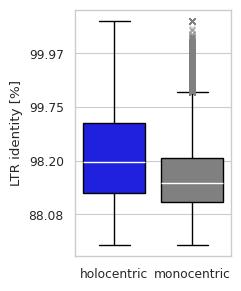

In [15]:
# Include all element families and group boxes by Centromere_architecture
plt.figure(figsize=(2.5, 3))
sns.set_theme(context="paper", style="whitegrid")
palette = {"holocentric": "#0000fff5", "monocentric": "gray"}


# Create the boxplot
ax = sns.boxplot(
    data=dante_with_centromere, 
    x="Centromere_architecture", 
    y="LTR_identity_logit", 
    hue="Centromere_architecture", 
    palette=palette, 
    dodge=False,
    linewidth=1, linecolor="black",
    flierprops=dict(marker='x', markersize=5, markeredgecolor='gray', alpha=0.3),
    whiskerprops=dict(color='black'), 
    capprops=dict(color='black'), 
    medianprops=dict(color='white'), 
    boxprops=dict(edgecolor='black')
)

# Apply the custom formatter to convert logit to percentage
ax.yaxis.set_major_formatter(FuncFormatter(logit_to_percent))

# Adjust plot aesthetics
plt.ylabel("LTR identity [%]")
plt.title("")
plt.xlabel("")
plt.tight_layout()
plt.savefig("data/figures/LTR_identity_all_families.svg", dpi=300)


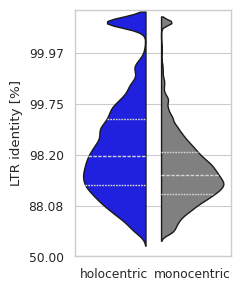

In [16]:
# Include all element families and group boxes by Centromere_architecture
plt.figure(figsize=(2.5, 3))
sns.set_theme(context="paper", style="whitegrid")
palette = {"holocentric": "#0000fff5", "monocentric": "gray"}

# Map the sample names to shorter labels
short_sample_labels = gs.set_index('Species').loc[sample_order, 'Short_label'].tolist()
dante_with_centromere['sample'] = dante_with_centromere['sample'].map(
    dict(zip(sample_order, short_sample_labels))
)

# Ensure the sample order is respected
dante_with_centromere['sample'] = pd.Categorical(
    dante_with_centromere['sample'], categories=short_sample_labels, ordered=True
)

# Create the violin plot
ax = sns.violinplot(
    data=dante_with_centromere, 
    x="Centromere_architecture", 
    y="LTR_identity_logit", 
    hue="Centromere_architecture", 
    palette=palette, 
    dodge=False,
    linecolor="k", split=True, inner="quartile"

)

# Apply the custom formatter to convert logit to percentage
ax.yaxis.set_major_formatter(FuncFormatter(logit_to_percent))
ax.set_ylim(logit_from_percent(50, eps=eps), 9.7)

for line in ax.lines:
    line.set_color('lightgray')
    
# Adjust plot aesthetics
plt.ylabel("LTR identity [%]")
plt.title("")
plt.xlabel("")
plt.tight_layout()
plt.savefig("data/figures/LTR_identity_all_families_violin.svg", dpi=300)


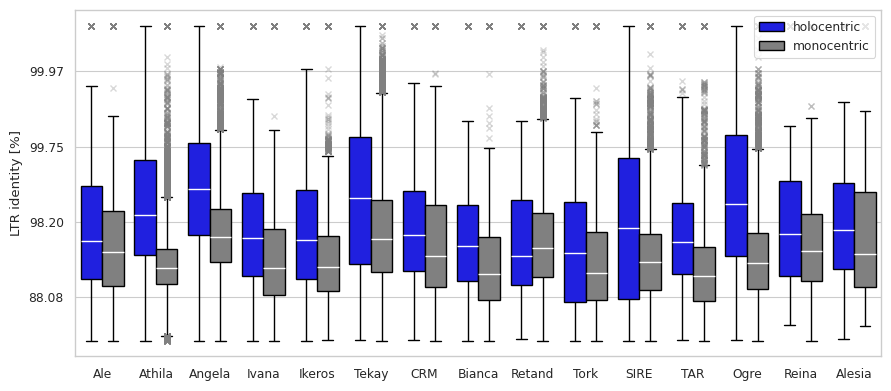

In [17]:
# Include all element families and group boxes by Centromere_architecture
plt.figure(figsize=(9, 4))
sns.set_theme(context="paper", style="whitegrid")
palette = {"holocentric": "#0000fff5", "monocentric": "gray"}

# Order the Class column by family_order
dante_with_centromere['Class'] = pd.Categorical(
    dante_with_centromere['Class'], categories=family_order, ordered=True
)

# Map Class to family_short_labels for x-axis labels
class_label_mapping = dict(zip(family_order, family_short_labels))
dante_with_centromere['Class_short'] = dante_with_centromere['Class'].map(class_label_mapping)

# Create the boxplot
ax = sns.boxplot(
    data=dante_with_centromere, 
    x="Class_short", 
    y="LTR_identity_logit", 
    hue="Centromere_architecture", 
    palette=palette, 
    dodge=True,
    linewidth=1, linecolor="black",
    flierprops=dict(marker='x', markersize=5, markeredgecolor='gray', alpha=0.3),
    whiskerprops=dict(color='black'), 
    capprops=dict(color='black'), 
    medianprops=dict(color='white'), 
    boxprops=dict(edgecolor='black')
)

# Apply the custom formatter to convert logit to percentage
ax.yaxis.set_major_formatter(FuncFormatter(logit_to_percent))

# Adjust plot aesthetics
plt.ylabel("LTR identity [%]")
plt.title("")
plt.xlabel("")
plt.tight_layout()
plt.legend(loc="upper right")
plt.savefig("data/figures/LTR_identity_all_families.svg", dpi=300)

/tmp/ipykernel_788305/900788789.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  class_counts = dante_with_centromere.groupby(['Class_short', 'Centromere_architecture']).size().unstack(fill_value=0)
/tmp/ipykernel_788305/900788789.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)


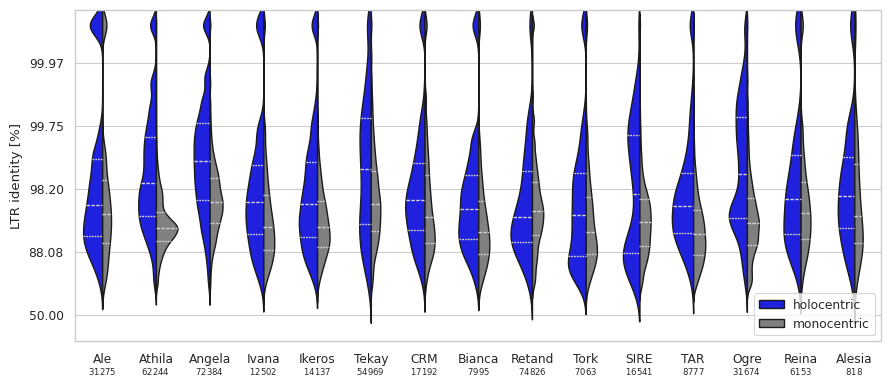

In [19]:
# Include all element families and group boxes by Centromere_architecture
plt.figure(figsize=(9, 4))
sns.set_theme(context="paper", style="whitegrid")
palette = {"holocentric": "#0000fff5", "monocentric": "gray"}

# Order the Class column by family_order
dante_with_centromere['Class'] = pd.Categorical(
    dante_with_centromere['Class'], categories=family_order, ordered=True
)

# Map Class to family_short_labels for x-axis labels
class_label_mapping = dict(zip(family_order, family_short_labels))
dante_with_centromere['Class_short'] = dante_with_centromere['Class'].map(class_label_mapping)

# Create the violin plot
ax = sns.violinplot(
    data=dante_with_centromere, 
    x="Class_short", 
    y="LTR_identity_logit", 
    hue="Centromere_architecture", 
    palette=palette, 
    dodge=True,
    linecolor="k", split=True, inner="quartile"

)

# Apply the custom formatter to convert logit to percentage
ax.yaxis.set_major_formatter(FuncFormatter(logit_to_percent))
ax.set_ylim(logit_from_percent(30, eps=eps), 9.7)

for line in ax.lines:
    line.set_color('lightgray')

# Calculate counts per class and centromere architecture
class_counts = dante_with_centromere.groupby(['Class_short', 'Centromere_architecture']).size().unstack(fill_value=0)

# Create new labels with counts
new_labels = []
for class_label in ax.get_xticklabels():
    class_name = class_label.get_text()
    holo_count = class_counts.loc[class_name, 'holocentric'] if class_name in class_counts.index else 0
    mono_count = class_counts.loc[class_name, 'monocentric'] if class_name in class_counts.index else 0
    total = holo_count + mono_count
    new_labels.append(f"{class_name}\n$^{{{total}}}$")

ax.set_xticklabels(new_labels)

# Adjust plot aesthetics
plt.ylabel("LTR identity [%]")
plt.title("")
plt.xlabel("")
plt.tight_layout()
plt.legend(loc="lower right")
plt.savefig("data/figures/LTR_identity_violin_all_families.svg", dpi=300)

# Non-logit version of the plot


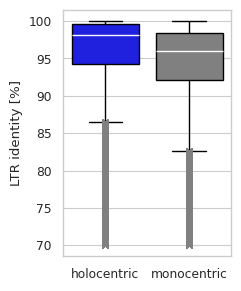

In [20]:
# Include all element families and group boxes by Centromere_architecture
plt.figure(figsize=(2.5, 3))
sns.set_theme(context="paper", style="whitegrid")
palette = {"holocentric": "#0000fff5", "monocentric": "gray"}

# Create the boxplot
ax = sns.boxplot(
    data=dante_with_centromere, 
    x="Centromere_architecture", 
    y="LTR_identity", 
    hue="Centromere_architecture", 
    palette=palette, 
    dodge=False,
    linewidth=1, linecolor="black",
    flierprops=dict(marker='x', markersize=5, markeredgecolor='gray', alpha=0.5),
    whiskerprops=dict(color='black'), 
    capprops=dict(color='black'), 
    medianprops=dict(color='white'), 
    boxprops=dict(edgecolor='black')
)

# Adjust plot aesthetics
plt.ylabel("LTR identity [%]")
plt.title("")
plt.xlabel("")
plt.tight_layout()
plt.savefig("data/figures/LTR_identity_boxplot.svg", dpi=300)

In [21]:
classic_16 = sns.color_palette("cubehelix", 16)
classic_16
#classic_16[9]

[(0.07854642984436605, 0.03982427647445866, 0.10693935497838603),
 (0.10425205507031031, 0.10540252695041774, 0.21985456650857077),
 (0.09280972177209738, 0.19719419690670295, 0.2934825545382206),
 (0.08238093761150347, 0.3001473774053336, 0.3044796804920607),
 (0.11361146455043755, 0.39175715201643607, 0.26270250537269685),
 (0.20939050075035193, 0.4532599402265316, 0.20636740939874193),
 (0.36346291565717626, 0.47877592702683464, 0.18407125030693286),
 (0.5427082667011206, 0.4783534231305908, 0.23224691345566498),
 (0.7017289791435338, 0.47369012876444405, 0.3583269956244587),
 (0.8029934134365606, 0.4885667981771633, 0.5371186858084777),
 (0.833415896487632, 0.5383418193146124, 0.7219329777744575),
 (0.809883922759887, 0.6232523833576228, 0.8654407503845682),
 (0.771147220055902, 0.7285891160099365, 0.9408568827998472),
 (0.7595750243941969, 0.8317666238369421, 0.9537691935676673),
 (0.8009580475986687, 0.9131944212213802, 0.9389160700563687),
 (0.8917231578965971, 0.9660085701840486, 0.942858319801462)]

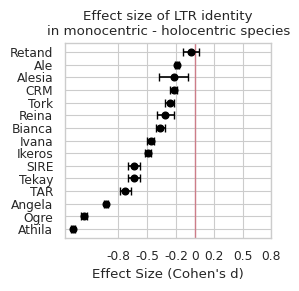

Check n per family (family, n_monocentric, n_holocentric):
('Ty1/copia|Ivana', 7020, 5482)
('Ty3/gypsy|chromovirus|CRM', 14177, 3015)
('Ty3/gypsy|non-chromovirus|OTA|Athila', 42058, 20186)
('Ty1/copia|Ikeros', 5893, 8244)
('Ty1/copia|Angela', 55738, 16646)
('Ty1/copia|Ale', 14185, 17090)
('Ty1/copia|Tork', 4198, 2865)
('Ty3/gypsy|non-chromovirus|OTA|Tat|Ogre', 27643, 4031)
('Ty1/copia|Alesia', 248, 570)
('Ty3/gypsy|chromovirus|Reina', 5593, 560)
('Ty1/copia|Bianca', 2825, 5170)
('Ty1/copia|SIRE', 15490, 1051)
('Ty3/gypsy|non-chromovirus|OTA|Tat|Retand', 74277, 549)
('Ty1/copia|TAR', 7206, 1571)
('Ty3/gypsy|chromovirus|Tekay', 53988, 981)


In [22]:
matplotlib.rcParams['font.family'] = "sans-serif"
matplotlib.rcParams['font.sans-serif'] = "Arial"
# Prepare data for the forest plot
effect_sizes = []
confidence_intervals = []
families = []
check_n = []


data = dante_with_centromere.copy()
data['Centromere_architecture'] = data['Centromere_architecture'].astype('category')
data['Class'] = data['Class'].astype('category')
data['LTR_identity_logit'] = data['LTR_identity_logit'].astype(float)

for family in data['Class'].unique():
    group1 = data[(data['Class'] == family) & (data['Centromere_architecture'] == 'monocentric')]['LTR_identity_logit']
    group2 = data[(data['Class'] == family) & (data['Centromere_architecture'] == 'holocentric')]['LTR_identity_logit']

    mean_diff = group1.mean() - group2.mean()
    pooled_std = np.sqrt(((group1.std()**2) * (len(group1) - 1) + (group2.std()**2) * (len(group2) - 1)) / (len(group1) + len(group2) - 2))
    cohen_d = mean_diff / pooled_std
    
    # Calculate standard error
    n1, n2 = len(group1), len(group2)
    se_cohens_d = np.sqrt((n1 + n2)/(n1 * n2) + (cohen_d**2)/(2*(n1 + n2)))
    ci_low = cohen_d - 1.96 * se_cohens_d
    ci_high = cohen_d + 1.96 * se_cohens_d
    
    effect_sizes.append(cohen_d)
    confidence_intervals.append((ci_low, ci_high))
    families.append(family.split("|")[-1])  # Use shorter family names
    check_n.append((family, n1, n2))


# Sort the data by effect size
sorted_indices = np.argsort(effect_sizes)
effect_sizes = [effect_sizes[i] for i in sorted_indices]
confidence_intervals = [confidence_intervals[i] for i in sorted_indices]
families = [families[i] for i in sorted_indices]

# Create the forest plot
fig, ax = plt.subplots(figsize=(3, 3))  # Adjust figure size if needed
y_pos = range(len(families))

# Extract confidence intervals
ci_lows = [ci[0] for ci in confidence_intervals]
ci_highs = [ci[1] for ci in confidence_intervals]

# Plot effect sizes with confidence intervals
sns.set_theme()
sns.set_context("paper")
sns.set_style("whitegrid")
ax.axvline(0, color=classic_16[9], linestyle='-', linewidth=1)
ax.errorbar(effect_sizes, y_pos, xerr=[np.array(effect_sizes) - np.array(ci_lows), np.array(ci_highs) - np.array(effect_sizes)], 
            fmt='o', color='black', ecolor='black', capsize=3)


x_ticks =[-0.8, -0.5, -0.2, 0, 0.2, 0.5, 0.8]
ax.set_xticks(x_ticks)
ax.set_xticklabels([str(x) for x in x_ticks])
# Set labels and title
ax.set_yticks(y_pos)
ax.set_yticklabels(families)
ax.set_xlabel("Effect Size (Cohen's d)")
ax.set_title("Effect size of LTR identity\nin monocentric - holocentric species")
plt.tight_layout()

# Save and show the plot
plt.savefig("data/figures/effect_sizes_forest_plot_with_ci.svg", dpi=300)
plt.show()

print("Check n per family (family, n_monocentric, n_holocentric):")
for item in check_n:
    print(item)
    


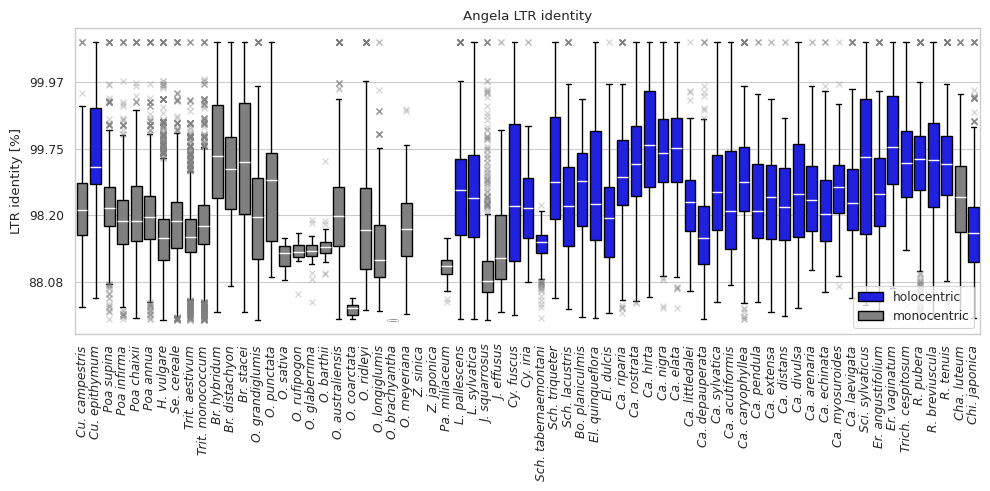

In [23]:
# Only Angela elements
angela_elements = dante_with_centromere[dante_with_centromere['Class'] == 'Ty1/copia|Angela'].copy()

palette = {"holocentric": "#0000fff5", "monocentric": "gray"}

plt.figure(figsize=(10, 5))
sns.set_theme(context="paper", style="whitegrid")

ax = sns.boxplot(
    data=angela_elements, 
    x="sample", 
    y="LTR_identity_logit", 
    hue="Centromere_architecture", 
    palette=palette, 
    dodge=False, 
    linewidth=1,  linecolor="black",
    flierprops=dict(marker='x', markersize=5, markeredgecolor='gray', alpha=0.3),
    whiskerprops=dict(color='black'), 
    capprops=dict(color='black'), 
    medianprops=dict(color='white'), 
    boxprops=dict(edgecolor='black')
)

# Apply the custom formatter to convert logit to percentage
ax.yaxis.set_major_formatter(FuncFormatter(logit_to_percent))

plt.xticks(rotation=90)
plt.ylabel("LTR identity [%]")
plt.xlabel("")
plt.title("Angela LTR identity")
plt.tight_layout()
plt.legend(loc="lower right")
# cursive x ticks
plt.xticks(fontstyle='italic')
plt.savefig("data/figures/Angela_LTR_identity.svg", dpi=300)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import pandas as pd

# Color palette for holocentric vs monocentric
palette = {"holocentric": "#0000fff5", "monocentric": "gray"}

# Loop through each element family
for family in dante_with_centromere['Class'].unique():
    
    # Filter data for this family
    family_elements = dante_with_centromere[dante_with_centromere['Class'] == family].copy()
    
    # Skip if not enough data
    if len(family_elements) < 10:
        print(f"Skipping {family}: insufficient data (n={len(family_elements)})")
        continue
    
    # Create figure
    plt.figure(figsize=(10, 5))
    sns.set_theme(context="paper", style="whitegrid")
    
    # Create boxplot
    ax = sns.boxplot(
        data=family_elements, 
        x="sample", 
        y="LTR_identity_logit", 
        hue="Centromere_architecture", 
        palette=palette, 
        dodge=False, 
        linewidth=1, linecolor="black",
        flierprops=dict(marker='x', markersize=5, markeredgecolor='gray', alpha=0.3),
        whiskerprops=dict(color='black'), 
        capprops=dict(color='black'), 
        medianprops=dict(color='white'), 
        boxprops=dict(edgecolor='black')
    )
    
    # Apply the custom formatter to convert logit to percentage
    ax.yaxis.set_major_formatter(FuncFormatter(logit_to_percent))
    
    # Get clean family name for title and filename
    family_short = family.split("|")[-1]
    
    # Styling
    plt.xticks(rotation=90, fontstyle='italic')
    plt.ylabel("LTR identity [%]")
    plt.xlabel("")
    plt.title(f"{family_short} LTR identity")
    plt.legend(loc="lower right")
    plt.tight_layout()
    
    # Save figure with family name
    filename = f"data/figures/{family_short}_LTR_identity.svg"
    plt.savefig(filename, dpi=300)
    plt.close()  # Close to free memory
    
    print(f"Saved: {filename}")

Saved: data/figures/Ivana_LTR_identity.svg
Saved: data/figures/CRM_LTR_identity.svg
Saved: data/figures/Athila_LTR_identity.svg
Saved: data/figures/Ikeros_LTR_identity.svg
Saved: data/figures/Angela_LTR_identity.svg
Saved: data/figures/Ale_LTR_identity.svg
Saved: data/figures/Tork_LTR_identity.svg
Saved: data/figures/Ogre_LTR_identity.svg
Saved: data/figures/Alesia_LTR_identity.svg
Saved: data/figures/Reina_LTR_identity.svg
Saved: data/figures/Bianca_LTR_identity.svg
Saved: data/figures/SIRE_LTR_identity.svg
Saved: data/figures/Retand_LTR_identity.svg
Saved: data/figures/TAR_LTR_identity.svg
Saved: data/figures/Tekay_LTR_identity.svg


: 

In [24]:
def prepare_for_joining(freq_df, feature_type):
    freq_df = freq_df.drop(columns=['Centromere_architecture', 'Assembly_size_in_analysis_(Mb)', 'sample'])
    freq_df = freq_df.melt(id_vars=['Short_label'], var_name='Class', value_name='count')
    freq_df['feature_type'] = feature_type
    return freq_df


dante_freq_prepared = prepare_for_joining(dante_freq, "intact")
solo_freq_prepared = prepare_for_joining(solo_freq, "solo")
disrupted_freq_prepared = prepare_for_joining(disrupted_freq, "disrupted")

# Combine all three dataframes
combined_freq = pd.concat([dante_freq_prepared, solo_freq_prepared, disrupted_freq_prepared], ignore_index=True)

# save the combined dataframe
combined_freq.to_csv("data/tables/combined_freq.tsv", sep="\t", index=False)

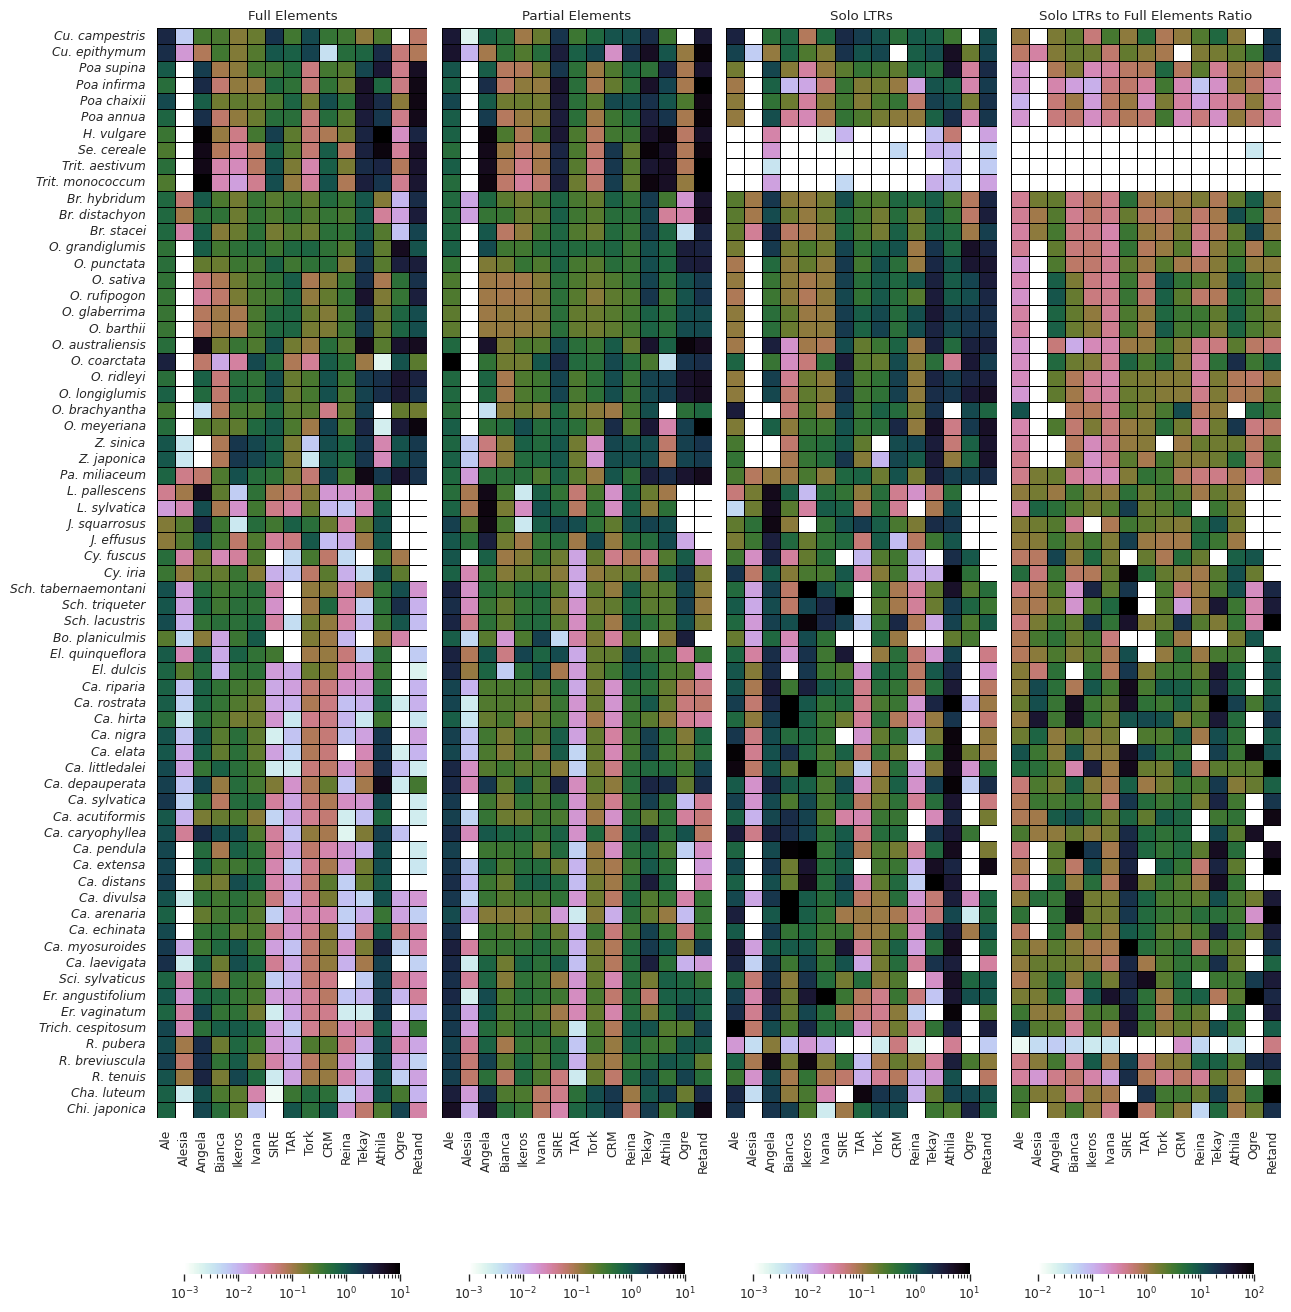

In [31]:
# plot the combined data as heatmap sublots
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

from matplotlib.colors import LogNorm


# color palette
heatmap_palette = sns.color_palette("cubehelix_r", as_cmap=True)

sns.set_theme(context="paper", style="white")


# Split the data into three subsets based on feature_type
intact_data = combined_freq[combined_freq['feature_type'] == 'intact']
solo_data = combined_freq[combined_freq['feature_type'] == 'solo']
disrupted_data = combined_freq[combined_freq['feature_type'] == 'disrupted']

# Create a pivot table for each subset
intact_pivot = intact_data.pivot(index='Short_label', columns='Class', values='count').fillna(0)
solo_pivot = solo_data.pivot(index='Short_label', columns='Class', values='count').fillna(0)
disrupted_pivot = disrupted_data.pivot(index='Short_label', columns='Class', values='count').fillna(0)
solo_to_intact_ratio = solo_pivot / (intact_pivot + 1e-6)

# Set up the figure and axes for subplots (2 rows: counts on top, ratio on bottom)
fig, axes = plt.subplots(1, 4, figsize=(13, 15),sharey=True)

# Shorten the labels
intact_pivot.columns = [x.split("|")[-1] for x in intact_pivot.columns]
solo_pivot.columns = [x.split("|")[-1] for x in solo_pivot.columns]
disrupted_pivot.columns = [x.split("|")[-1] for x in disrupted_pivot.columns]
solo_to_intact_ratio.columns = [x.split("|")[-1] for x in solo_to_intact_ratio.columns]

# Reorder the samples and set shorter labels
intact_pivot = intact_pivot.loc[short_labels]
solo_pivot = solo_pivot.loc[short_labels]
disrupted_pivot = disrupted_pivot.loc[short_labels]
solo_to_intact_ratio = solo_to_intact_ratio.loc[short_labels]

# Log-transform the ratio
solo_to_intact_ratio_log = np.log10(solo_to_intact_ratio + 1)


sns.heatmap(intact_pivot, cmap=heatmap_palette, norm=LogNorm(vmin=1e-3, vmax=1e1), ax=axes[0], 
            cbar=True, cbar_kws={"orientation": "horizontal", "shrink": 0.8, "pad": 0.1}, 
            linewidths=0.5, linecolor='black')
axes[0].set_title("Full Elements")
axes[0].set_ylabel("")
axes[0].set_xticks(np.arange(len(intact_pivot.columns)) + 0.5)
axes[0].set_xticklabels(intact_pivot.columns, rotation=90, ha='center')
axes[0].set_yticks(np.arange(len(intact_pivot.index)) + 0.5)
axes[0].set_yticklabels(short_sample_labels, va='center', fontstyle='italic')

sns.heatmap(disrupted_pivot, cmap=heatmap_palette, norm=LogNorm(vmin=1e-3, vmax=1e1), ax=axes[1], 
            cbar=True, cbar_kws={"orientation": "horizontal", "shrink": 0.8, "pad": 0.1}, 
            linewidths=0.5, linecolor='black')
axes[1].set_title("Partial Elements")
axes[1].set_ylabel("")
axes[1].set_xticks(np.arange(len(disrupted_pivot.columns)) + 0.5)
axes[1].set_xticklabels(disrupted_pivot.columns, rotation=90, ha='center')
axes[1].set_yticks(np.arange(len(disrupted_pivot.index)) + 0.5)
axes[1].set_yticklabels(short_sample_labels, va='center', fontstyle='italic')

sns.heatmap(solo_pivot, cmap=heatmap_palette, norm=LogNorm(vmin=1e-3, vmax=1e1), ax=axes[2], 
            cbar=True, cbar_kws={"orientation": "horizontal", "shrink": 0.8, "pad": 0.1}, 
            linewidths=0.5, linecolor='black')
axes[2].set_title("Solo LTRs")
axes[2].set_ylabel("")
axes[2].set_xticks(np.arange(len(solo_pivot.columns)) + 0.5)
axes[2].set_xticklabels(solo_pivot.columns, rotation=90, ha='center')
axes[2].set_yticks(np.arange(len(solo_pivot.index)) + 0.5)
axes[2].set_yticklabels(short_sample_labels, va='center', fontstyle='italic')

sns.heatmap(solo_to_intact_ratio, cmap=heatmap_palette, norm=LogNorm(vmin=1e-2, vmax=100), ax=axes[3], 
            cbar=True, cbar_kws={"orientation": "horizontal", "shrink": 0.8, "pad": 0.1}, 
            linewidths=0.5, linecolor='black')
axes[3].set_title("Solo LTRs to Full Elements Ratio")
axes[3].set_ylabel("")
axes[3].set_xticks(np.arange(len(solo_to_intact_ratio.columns)) + 0.5)
axes[3].set_xticklabels(solo_to_intact_ratio.columns, rotation=90, ha='center')
axes[3].set_yticks(np.arange(len(solo_to_intact_ratio.index)) + 0.5)
axes[3].set_yticklabels(short_sample_labels, va='center', fontstyle='italic')

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig("data/figures/LTRTE_combined_freq_subplots.svg", format='svg', dpi=300)

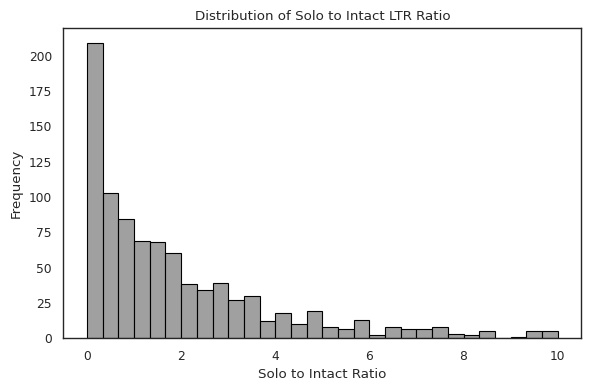

: 

In [ ]:
# histogram of solo to intact ratio values, 30 bins in range 0, 10
plt.figure(figsize=(6, 4))
sns.histplot(solo_to_intact_ratio.values.flatten(), bins=30, binrange=(0, 10), color='gray', edgecolor='black')

plt.xlabel("Solo to Intact Ratio")
plt.ylabel("Frequency")
plt.title("Distribution of Solo to Intact LTR Ratio")
plt.tight_layout()

In [ ]:
from matplotlib import font_manager

# Add fonts from the new directory to matplotlib
custom_fonts_path = "config/fonts"
custom_fonts = font_manager.findSystemFonts(fontpaths=custom_fonts_path, fontext='ttf')
for font in custom_fonts:
    try:
        font_manager.fontManager.addfont(font)
    except Exception as e:
        print(f"Skipping font {font} due to error: {e}")


matplotlib.rcParams['font.family'] = "sans-serif"
matplotlib.rcParams['font.sans-serif'] = "Arial"

sorted(font_manager.get_font_names())


Skipping font /auto/brno12-cerit/nfs4/home/kratka/brno1/LTR-TE_dynamics/config/fonts/fonts/truetype/noto/NotoColorEmoji.ttf due to error: Can not load face (unknown file format; error code 0x2)


['Abyssinica SIL',
 'Ani',
 'AnjaliOldLipi',
 'Arial',
 'Arial Black',
 'Arial CE',
 'Arial CE MT Black',
 'Arial Light',
 'C059',
 'Chandas',
 'Chilanka',
 'Classic Console',
 'D050000L',
 'DejaVu Math TeX Gyre',
 'DejaVu Sans',
 'DejaVu Sans Display',
 'DejaVu Sans Mono',
 'DejaVu Serif',
 'DejaVu Serif Display',
 'Dhurjati',
 'Droid Sans Fallback',
 'Dyuthi',
 'FreeMono',
 'FreeSans',
 'FreeSerif',
 'Gargi',
 'Garuda',
 'Gayathri',
 'Gidugu',
 'Gubbi',
 'Gurajada',
 'Jamrul',
 'KacstArt',
 'KacstBook',
 'KacstDecorative',
 'KacstDigital',
 'KacstFarsi',
 'KacstLetter',
 'KacstNaskh',
 'KacstOffice',
 'KacstOne',
 'KacstPen',
 'KacstPoster',
 'KacstQurn',
 'KacstScreen',
 'KacstTitle',
 'KacstTitleL',
 'Kalapi',
 'Kalimati',
 'Karumbi',
 'Keraleeyam',
 'Khmer OS',
 'Khmer OS System',
 'Kinnari',
 'LKLUG',
 'LakkiReddy',
 'Laksaman',
 'Lato',
 'Liberation Mono',
 'Liberation Sans',
 'Liberation Sans Narrow',
 'Liberation Serif',
 'Likhan',
 'Lohit Assamese',
 'Lohit Bengali',
 'Lohit 

: 

In [ ]:
import pandas as pd
# if combined freq table not loaded, load it
if 'combined_freq' not in locals():
    combined_freq = pd.read_csv("data/combined_freq.tsv", sep="\t")

# pivot table  to species x family x intact x disrupted x solo
pivot_table = combined_freq.pivot_table(index=['Short_label', 'Class'], columns='feature_type', values='count')
# split the index into two columns
pivot_table = pivot_table.reset_index()
# save the pivot table
pivot_table.to_csv("data/tables/combined_freq_pivoted.tsv", sep="\t", index=False)


: 

/tmp/ipykernel_897066/2047309320.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_pivot['Short_label'] = filtered_pivot['Short_label'].str.replace('_', ' ')


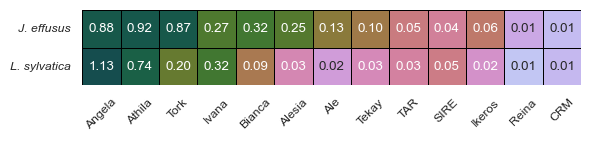

: 

In [ ]:
# heatmap of abundance of intact elements in L. sylvatica and J. effusus
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

if not 'pivot_table' in locals():
    pivot_table = pd.read_csv("data/tables/combined_freq_pivoted.tsv", sep="\t")
# filter the pivot table for L. sylvatica and J. effusus
filtered_pivot = pivot_table[pivot_table['Short_label'].isin(['L. sylvatica', 'J. effusus'])]
# replace _ with space in sample names
filtered_pivot['Short_label'] = filtered_pivot['Short_label'].str.replace('_', ' ')
# get rid of rows where both is 0
filtered_pivot = filtered_pivot[(filtered_pivot['intact'] > 0)]
# pivot the table to have samples as rows
heatmap_data = filtered_pivot.pivot(index='Short_label', columns='Class', values='intact').fillna(0)
# shorten the column names
heatmap_data.columns = [x.split("|")[-1] for x in heatmap_data.columns]

# family order based on sum of intact elements
family_sums = heatmap_data.sum(axis=0).sort_values(ascending=False)
heatmap_data = heatmap_data[family_sums.index]

# create the heatmap
plt.figure(figsize=(6, 1.5))
sns.set_theme(context="paper", style="white")
heatmap_palette = sns.color_palette("cubehelix_r", as_cmap=True)
sns.heatmap(heatmap_data, cmap=heatmap_palette, norm=LogNorm(vmin=1e-3, vmax=1e1), 
            cbar=False,
            linewidths=0.5, linecolor='black', annot=True, fmt=".2f")
plt.ylabel("")
plt.xlabel("")
plt.xticks(rotation=45, ha='center')
plt.yticks(rotation=0, va='center', fontstyle='italic')
plt.tight_layout()
plt.savefig("data/figures/Luzula_Juncus_intact_LTRTE_heatmap.svg", format='svg', dpi=300)
 